# YouGov Climate Survey — Exploratory Data Analysis

This notebook provides a comprehensive descriptive analysis of the YouGov climate attitudes survey
data (University of Leeds, January 2024). The data underpins the agent population in Climate-Action-GABM.

**Sections:**
1. Data loading and overview
2. Demographics (age, gender, region, ethnicity, education, income)
3. Political profile (left-right, UKGE2019, Brexit referendum)
4. **Climate policy support** — the 6 policies (primary outcome)
5. Values and worldview scales (Schwartz values, SDO, EDO, RWA)
6. Climate emotions (worry, hope, anger)
7. Policy support by demographics and political subgroups
8. Correlation structure across policies, values, and politics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/yougov_survey_data/YouGovProcessedData.csv")
print(f"N = {len(df):,} respondents, {df.shape[1]} variables")

N = 1,967 respondents, 162 variables


The dataset comprises **1,967 respondents** across **162 variables**, collected by YouGov in partnership with the University of Leeds (January 2024). This is a large, nationally representative UK sample with rich attitudinal, demographic, and political data.

## 1. Data Overview

In [3]:
# Missing data summary (only columns with any nulls)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
display(missing.to_frame("n_missing").assign(pct=lambda x: x["n_missing"] / len(df) * 100).round(1))

Columns with missing values: 5 / 162


,n_missing,pct
tprofile_gross_household,398,20.2
TrustStrangers,100,5.1
TrustParliament,50,2.5
TrustGovernment,43,2.2
Political_Left_Right,6,0.3


**Missing data** is concentrated in a small number of columns. The core demographic and policy variables are nearly complete, meaning we can use the full sample for most analyses without imputation.

## 2. Demographics

In [4]:
# ── Label mappings ──────────────────────────────────────────
GENDER_MAP = {0: "Female", 1: "Male"}

REGION_MAP = {
    0: "Unknown", 1: "North East", 2: "North West",
    3: "Yorkshire & Humber", 4: "East Midlands", 5: "West Midlands",
    6: "East of England", 7: "London", 8: "South East",
    9: "South West", 10: "Wales", 11: "Scotland", 12: "Northern Ireland",
}

ETHNICITY_MAP = {0: "Unknown", 1: "White", 2: "Asian", 3: "Black", 4: "Mixed", 5: "Other"}

POLITICS_MAP = {
    1: "Very left", 2: "Fairly left", 3: "Slightly left",
    4: "Centre", 5: "Slightly right", 6: "Fairly right",
    7: "Very right", 8: "Don't know",
}

BREXIT_MAP = {1: "Remain", 2: "Leave", 3: "Don't know", 4: "Unknown"}

GE2019_MAP = {
    1: "Conservative", 2: "Labour", 3: "Lib Dem",
    4: "Brexit", 5: "Green", 6: "Other", 7: "Don't know",
}

# ── Climate policy columns ──────────────────────────────────
POLICY_COLS = {
    "Renewable Energy": "page5posttreatment6_1",
    "Ban Fossil Fuels": "page5posttreatment6_4",
    "Ban Petrol Cars": "page5posttreatment6_5",
    "Green Housing": "page5posttreatment6_7",
    "Carbon Tax": "page5posttreatment6_9",
    "Climate Compensation": "page5posttreatment6_11",
}

RESPONSE_LABELS = {
    1: "Strongly oppose", 2: "Somewhat oppose", 3: "Slightly oppose",
    4: "Neutral", 5: "Slightly support", 6: "Somewhat support", 7: "Strongly support",
}

print("Label mappings loaded.")

Label mappings loaded.


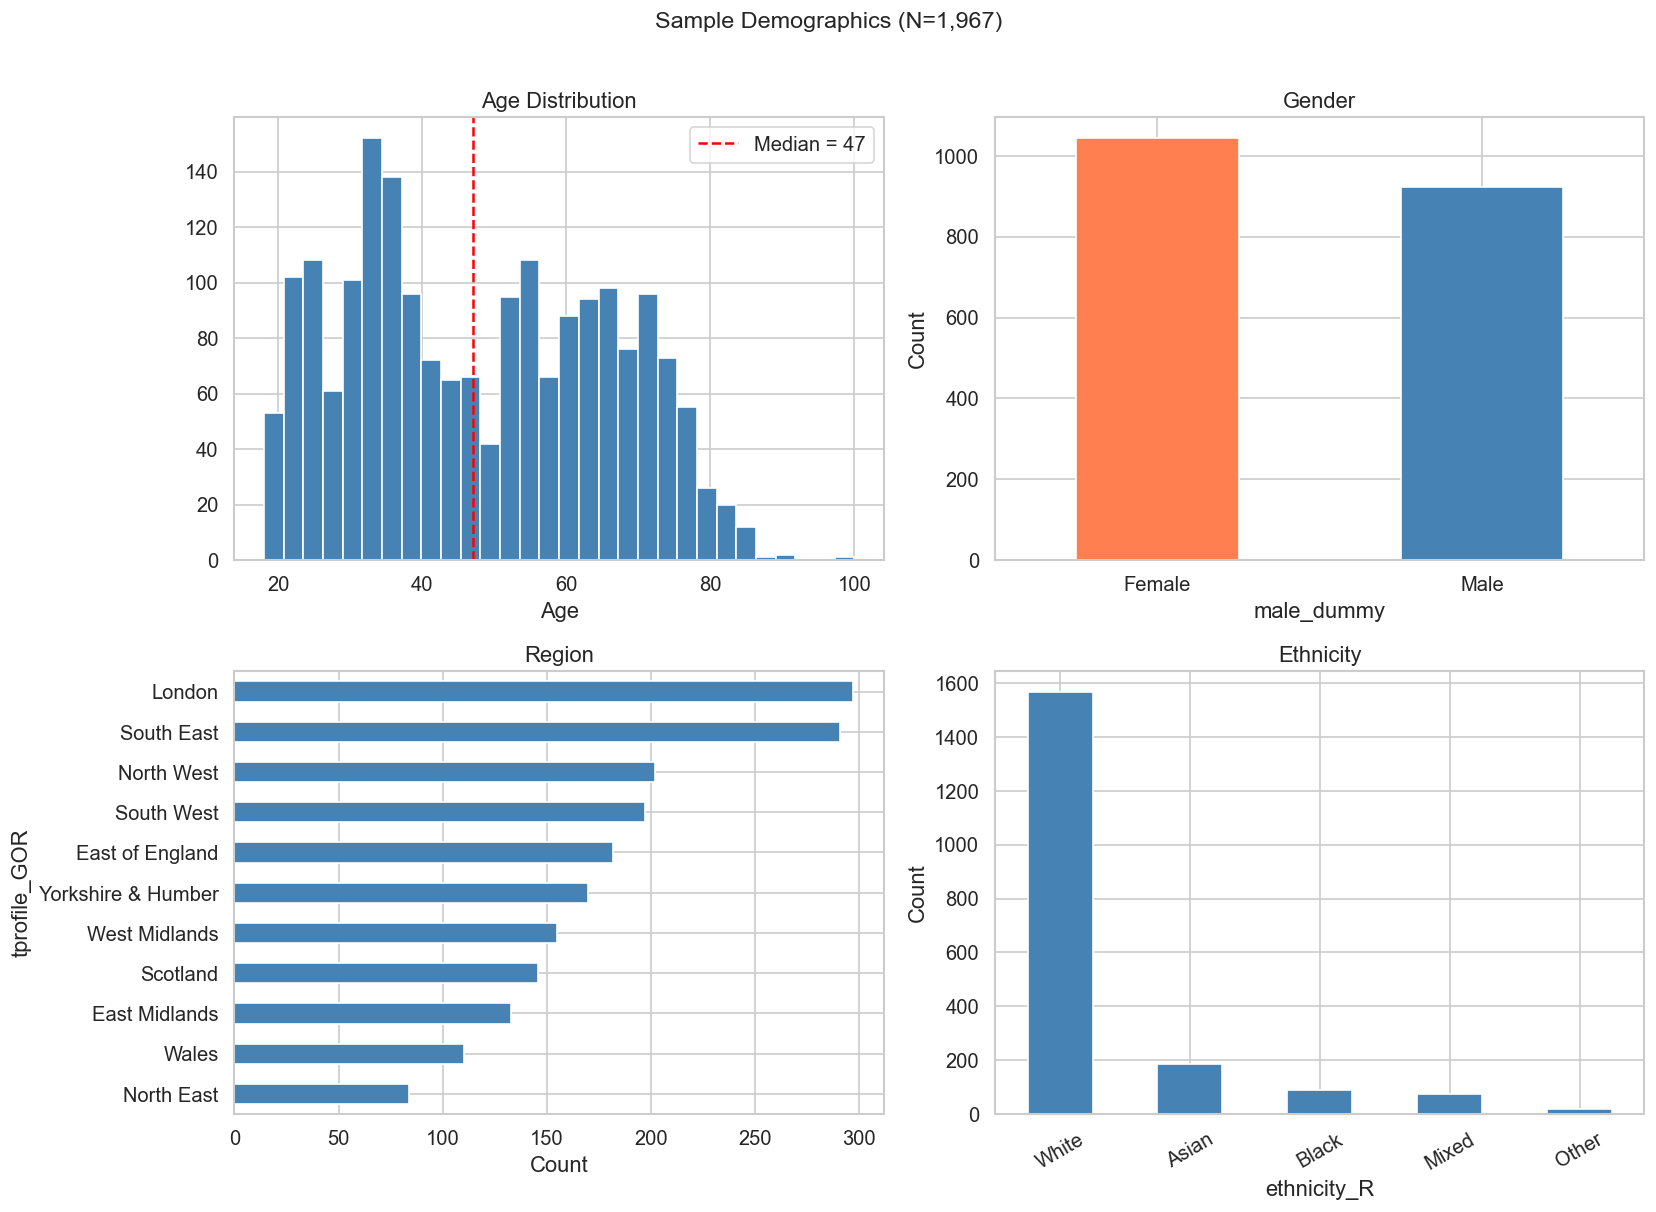

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
ax = axes[0, 0]
df["age"].clip(upper=100).hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(df["age"].median(), color="red", ls="--", label=f"Median = {df['age'].median():.0f}")
ax.set_xlabel("Age")
ax.set_title("Age Distribution")
ax.legend()

# Gender
ax = axes[0, 1]
df["male_dummy"].map(GENDER_MAP).value_counts().plot.bar(ax=ax, color=["coral", "steelblue"])
ax.set_title("Gender")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

# Region
ax = axes[1, 0]
region_counts = df["tprofile_GOR"].map(REGION_MAP).value_counts()
region_counts = region_counts.drop("Unknown", errors="ignore")
region_counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("Region")
ax.set_xlabel("Count")

# Ethnicity
ax = axes[1, 1]
eth_counts = df["ethnicity_R"].map(ETHNICITY_MAP).value_counts()
eth_counts = eth_counts.drop("Unknown", errors="ignore")
eth_counts.plot.bar(ax=ax, color="steelblue")
ax.set_title("Ethnicity")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)

fig.suptitle("Sample Demographics (N={:,})".format(len(df)), fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Key demographic observations:**
- **Age** is broadly distributed (18–90+) with a median of 47 and a slight left-skew toward younger respondents (30s peak).
- **Gender** is close to balanced, with a slight female majority (~53% female, 47% male).
- **Region** covers all 11 UK Government Office Regions plus Northern Ireland. London and the South East are the most represented; North East the least.
- **Ethnicity** is overwhelmingly White (~80%), with Asian, Black, Mixed, and Other groups each comprising small minorities — consistent with UK national proportions.

In [6]:
# Summary statistics table
demo_summary = pd.DataFrame({
    "N": len(df),
    "Male %": f"{df['male_dummy'].mean():.1%}",
    "Age (mean ± SD)": f"{df['age'].mean():.1f} ± {df['age'].std():.1f}",
    "Age (median)": f"{df['age'].median():.0f}",
    "White %": f"{(df['ethnicity_R'] == 1).mean():.1%}",
    "Parent %": f"{df['parent_dummy'].mean():.1%}",
    "Academic %": f"{df['academic_dummy'].mean():.1%}",
}, index=["Sample"])
display(demo_summary.T.rename(columns={"Sample": "Value"}))

,Value
N,1967
Male %,47.0%
Age (mean ± SD),48.0 ± 17.9
Age (median),47
White %,79.6%
Parent %,55.6%
Academic %,42.9%


The sample is roughly representative of the UK adult population: **47% male**, mean age **~48**, majority White, with about half holding an academic qualification and half being parents. These demographics provide a credible foundation for generalising survey findings to UK public opinion.

## 3. Political Profile

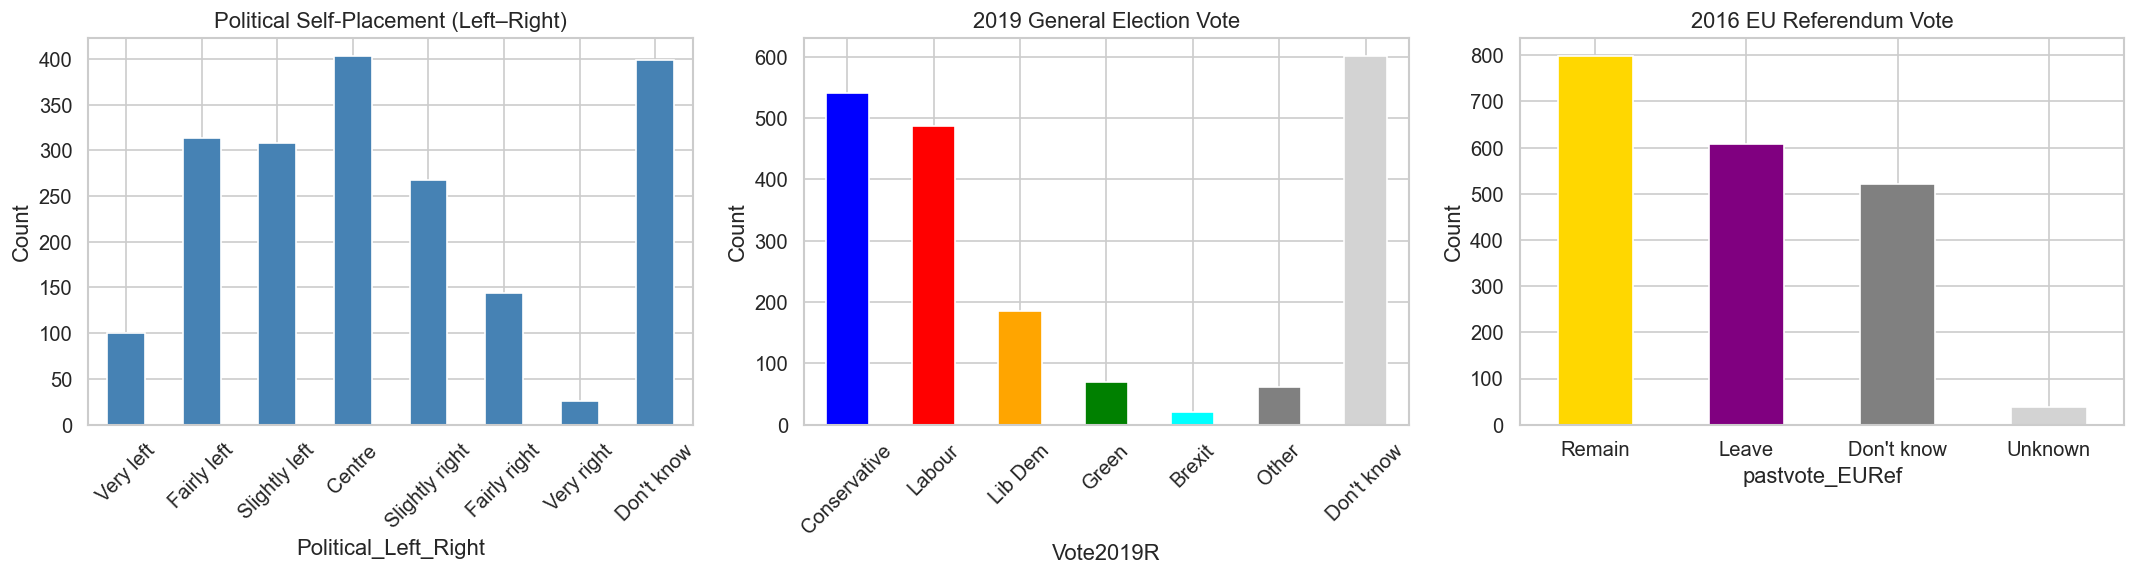

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left-Right self-placement
ax = axes[0]
lr = df["Political_Left_Right"].dropna().astype(int).map(POLITICS_MAP)
order = [POLITICS_MAP[i] for i in range(1, 9)]
lr.value_counts().reindex(order).plot.bar(ax=ax, color="steelblue")
ax.set_title("Political Self-Placement (Left–Right)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

# UKGE2019 vote
ax = axes[1]
ge = df["Vote2019R"].map(GE2019_MAP)
ge_order = [GE2019_MAP[i] for i in [1, 2, 3, 5, 4, 6, 7]]
ge.value_counts().reindex(ge_order).plot.bar(ax=ax, color=["blue", "red", "orange", "green", "cyan", "grey", "lightgrey"])
ax.set_title("2019 General Election Vote")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

# Brexit vote
ax = axes[2]
bx = df["pastvote_EURef"].map(BREXIT_MAP)
bx_order = ["Remain", "Leave", "Don't know", "Unknown"]
bx.value_counts().reindex(bx_order).plot.bar(ax=ax, color=["gold", "purple", "grey", "lightgrey"])
ax.set_title("2016 EU Referendum Vote")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Key political observations:**
- **Left-Right self-placement** has a large "Don't know" category (~400), with the remainder roughly normally distributed around Centre. The left side (Very/Fairly/Slightly left combined) slightly outnumbers the right.
- **2019 General Election**: Conservative (~530) and Labour (~480) dominate, followed by Lib Dem (~190). Green and Brexit Party voters are present but small.
- **EU Referendum**: Remain (~800) slightly outnumbers Leave (~620), with a substantial "Don't know" group (~500) — likely including non-voters and younger respondents ineligible in 2016.

## 4. Climate Policy Support — The Six Policies

The central outcome measures. The survey asks respondents how much they support or oppose six specific climate policies on a 7-point scale (1 = Strongly oppose, 4 = Neutral, 7 = Strongly support).

In [8]:
# ── Summary table: mean, median, SD, % support (5-7), % oppose (1-3), % neutral (4) ──
rows = []
for name, col in POLICY_COLS.items():
    s = df[col]
    rows.append({
        "Policy": name,
        "Mean": s.mean(),
        "SD": s.std(),
        "Median": s.median(),
        "% Support (5-7)": (s >= 5).mean() * 100,
        "% Neutral (4)": (s == 4).mean() * 100,
        "% Oppose (1-3)": (s <= 3).mean() * 100,
        "Net Support": ((s >= 5).mean() - (s <= 3).mean()) * 100,
    })
policy_summary = pd.DataFrame(rows).set_index("Policy")
display(policy_summary.round(1).style.background_gradient(subset=["Net Support"], cmap="RdYlGn"))

,Mean,SD,Median,% Support (5-7),% Neutral (4),% Oppose (1-3),Net Support
Policy,,,,,,,
Renewable Energy,5.600000,1.500000,6.000000,78.600000,14.700000,6.700000,71.900000
Ban Fossil Fuels,4.400000,1.800000,4.000000,43.200000,30.500000,26.300000,16.900000
Ban Petrol Cars,3.900000,2.000000,4.000000,38.700000,20.100000,41.200000,-2.500000
Green Housing,5.500000,1.600000,6.000000,75.700000,13.900000,10.400000,65.300000
Carbon Tax,4.400000,1.700000,4.000000,46.600000,31.700000,21.800000,24.800000
Climate Compensation,3.900000,1.800000,4.000000,37.700000,26.700000,35.600000,2.000000


**Policy support summary — the central finding:**

The six policies fall into three tiers of public support:
1. **High support**: Renewable Energy (μ=5.64) and Green Housing (μ=5.50) — both enjoy >75% support (ratings 5–7) with <10% opposition. Net support exceeds +65 percentage points.
2. **Moderate / mixed**: Ban Fossil Fuels (μ=4.37) and Carbon Tax (μ=4.42) — majority lean supportive but with a large neutral bloc (~30%) and ~20% opposition.
3. **Contested**: Ban Petrol Cars (μ=3.92) and Climate Compensation (μ=3.91) — nearly evenly split between supporters and opponents. Net support is close to zero or negative, making these the most politically divisive climate policies in the sample.

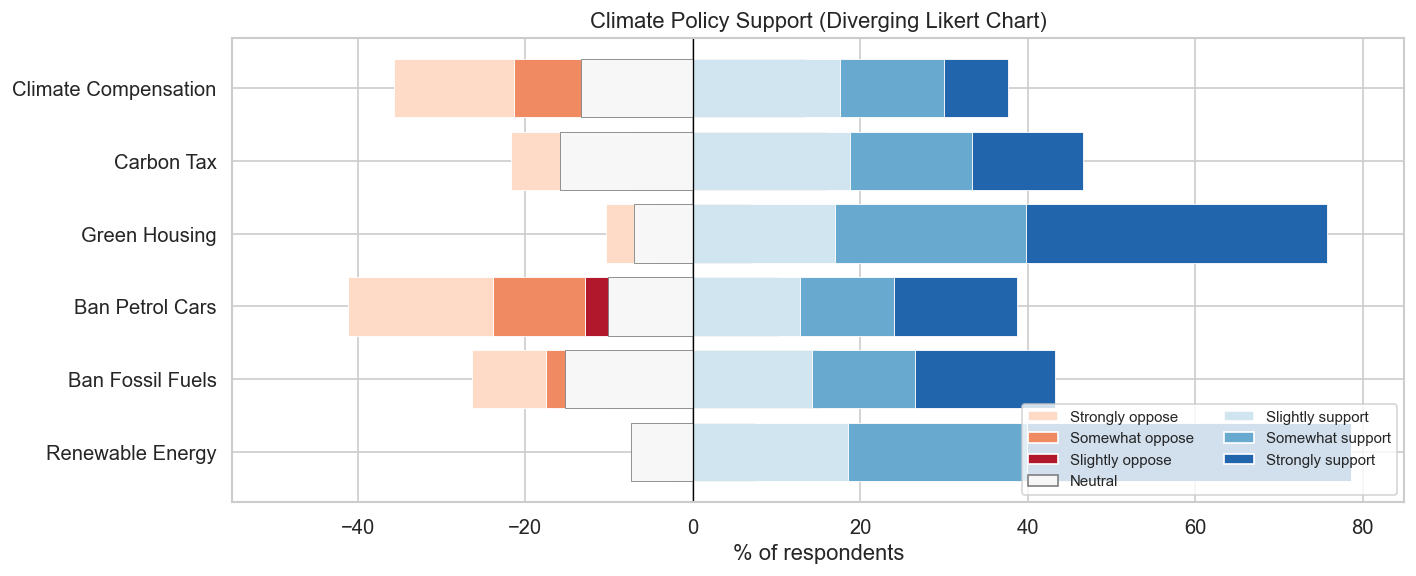

In [9]:
# ── Diverging stacked bar chart (Likert-style) ──────────────
fig, ax = plt.subplots(figsize=(12, 5))

policy_names = list(POLICY_COLS.keys())
colors_oppose = ["#b2182b", "#ef8a62", "#fddbc7"]
color_neutral = "#f7f7f7"
colors_support = ["#d1e5f0", "#67a9cf", "#2166ac"]

y_pos = np.arange(len(policy_names))

for i, (name, col) in enumerate(POLICY_COLS.items()):
    counts = df[col].value_counts(normalize=True).sort_index() * 100
    # Ensure all 7 levels present
    counts = counts.reindex(range(1, 8), fill_value=0)
    
    # Plot oppose bars (going left from centre)
    left = 0
    for level in [3, 2, 1]:  # slightly, somewhat, strongly oppose
        width = counts[level]
        left -= width
        ax.barh(i, width, left=left, color=colors_oppose[3 - level],
                edgecolor="white", linewidth=0.5)
    
    # Neutral (centred on 0)
    neutral_w = counts[4]
    ax.barh(i, neutral_w, left=-neutral_w / 2, color=color_neutral,
            edgecolor="grey", linewidth=0.5)
    
    # Support bars (going right from centre)
    left = 0
    for j, level in enumerate([5, 6, 7]):
        width = counts[level]
        ax.barh(i, width, left=left, color=colors_support[j],
                edgecolor="white", linewidth=0.5)
        left += width

ax.set_yticks(y_pos)
ax.set_yticklabels(policy_names)
ax.set_xlabel("% of respondents")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Climate Policy Support (Diverging Likert Chart)")
ax.set_xlim(-55, 85)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_oppose[2], label="Strongly oppose"),
    Patch(facecolor=colors_oppose[1], label="Somewhat oppose"),
    Patch(facecolor=colors_oppose[0], label="Slightly oppose"),
    Patch(facecolor=color_neutral, edgecolor="grey", label="Neutral"),
    Patch(facecolor=colors_support[0], label="Slightly support"),
    Patch(facecolor=colors_support[1], label="Somewhat support"),
    Patch(facecolor=colors_support[2], label="Strongly support"),
]
ax.legend(handles=legend_elements, loc="lower right", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

The diverging Likert chart makes the three-tier structure visually clear. **Renewable Energy** and **Green Housing** bars extend far to the right with almost no left (opposition) component. **Ban Petrol Cars** has the largest opposition bar, extending past −40%, while its support side barely offsets this — confirming it as the most polarising policy. **Climate Compensation** shows a similar split but with more respondents in the "slightly" categories on both sides, indicating weaker conviction.

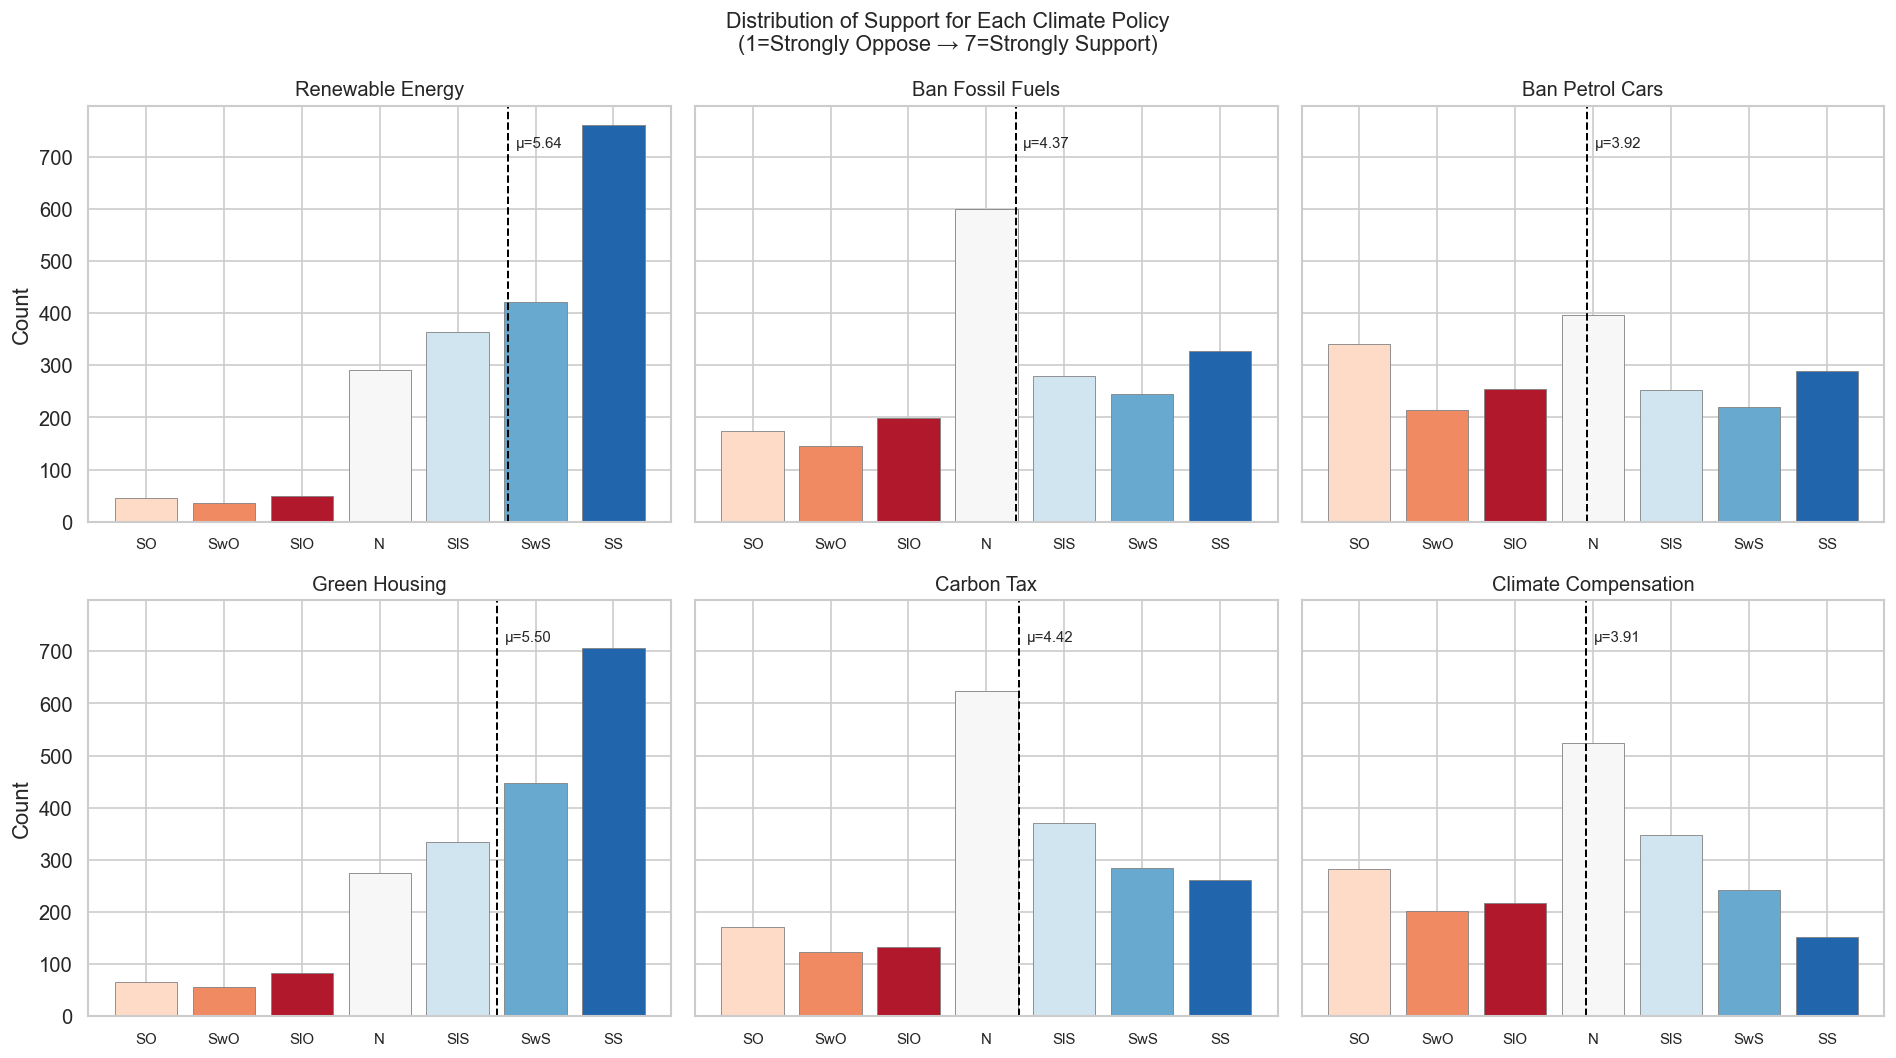

In [10]:
# ── Distribution histograms for each policy ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

for ax, (name, col) in zip(axes.flat, POLICY_COLS.items()):
    counts = df[col].value_counts().reindex(range(1, 8), fill_value=0)
    colors = [colors_oppose[2], colors_oppose[1], colors_oppose[0],
              color_neutral,
              colors_support[0], colors_support[1], colors_support[2]]
    bars = ax.bar(range(1, 8), counts.values, color=colors, edgecolor="grey", linewidth=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(["SO", "SwO", "SlO", "N", "SlS", "SwS", "SS"], fontsize=9)
    ax.set_xlabel("")
    # Add mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="black", ls="--", linewidth=1.2)
    ax.text(mean_val + 0.1, ax.get_ylim()[1] * 0.9, f"μ={mean_val:.2f}", fontsize=9)

axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")
fig.suptitle("Distribution of Support for Each Climate Policy\n(1=Strongly Oppose → 7=Strongly Support)", fontsize=13)
plt.tight_layout()
plt.show()

The per-policy histograms reveal distinct distributional shapes:
- **Renewable Energy** and **Green Housing** are strongly right-skewed — the modal response is "Strongly support" (7), with very few respondents on the oppose end.
- **Ban Fossil Fuels** has its largest bar at Neutral (4), with a secondary peak at "Strongly support" — a bimodal hint.
- **Ban Petrol Cars** is the flattest distribution, nearly uniform across all 7 levels, indicating genuine polarisation rather than simple indifference.
- **Carbon Tax** peaks at Neutral with a gradual decline toward both extremes.
- **Climate Compensation** also peaks at Neutral, with a roughly symmetric decline — the most "undecided" policy.

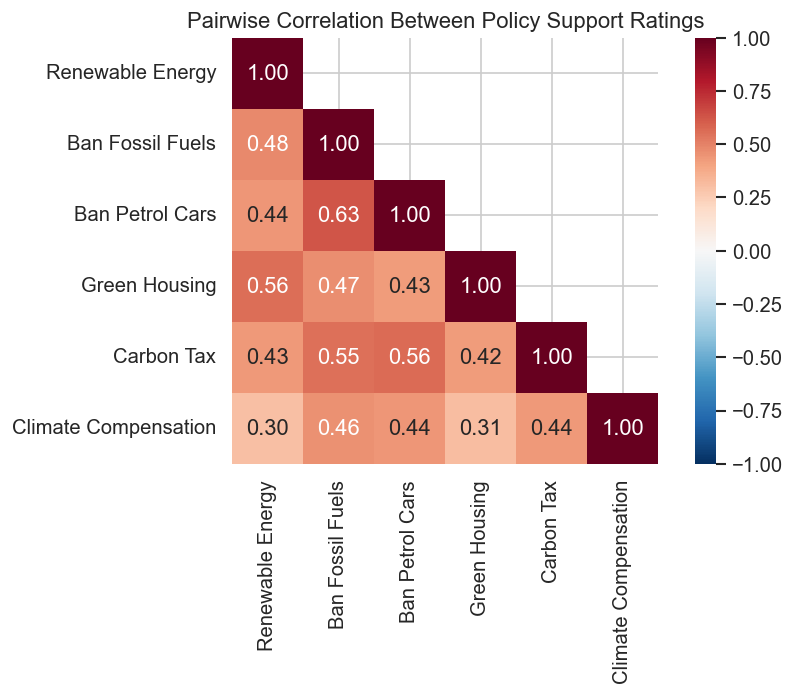

In [11]:
# ── Inter-policy correlation matrix ─────────────────────────
policy_df = df[[col for col in POLICY_COLS.values()]].copy()
policy_df.columns = list(POLICY_COLS.keys())

corr = policy_df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax, square=True)
ax.set_title("Pairwise Correlation Between Policy Support Ratings")
plt.tight_layout()
plt.show()

All six policies are **positively correlated** (r = 0.30–0.63), confirming a latent "climate policy support" dimension. The strongest pair is **Ban Fossil Fuels ↔ Ban Petrol Cars** (r = 0.63) — both involve banning existing technologies. **Renewable Energy ↔ Green Housing** (r = 0.56) form a second cluster of "investment-oriented" policies. **Climate Compensation** has the weakest ties to the other policies (r ≈ 0.30–0.46), suggesting it taps a distinct redistributive attitude beyond general environmentalism.

## 5. Values & Worldview Scales

Composite psychological scales included in the survey:
- **Self-transcendence** / **Self-enhancement** (Schwartz values)
- **Openness** / **Conformity-Tradition** (Schwartz values)
- **SDO** — Social Dominance Orientation
- **EDO** — Environmental Dominance Orientation
- **RWA** — Right-Wing Authoritarianism

In [12]:
VALUE_COLS = {
    "Self-transcendence": "Selftransc_Val",
    "Self-enhancement": "Selfenh_Values",
    "Openness": "Openness",
    "Conformity-Tradition": "ConformTrad",
    "SDO": "SDO",
    "EDO": "EDO",
    "RWA": "RWA",
}

val_stats = pd.DataFrame({
    name: df[col].describe().round(2)
    for name, col in VALUE_COLS.items()
}).T
display(val_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]])

,mean,std,min,25%,50%,75%,max
Self-transcendence,4.58,0.86,1.0,4.00,4.67,5.17,6.0
Self-enhancement,2.87,1.02,1.0,2.00,2.75,3.50,6.0
Openness,3.78,0.90,1.0,3.25,3.75,4.50,6.0
Conformity-Tradition,3.80,1.08,1.0,3.00,3.75,4.50,6.0
SDO,2.92,1.01,1.0,2.12,3.00,3.75,7.0
EDO,3.36,1.26,1.0,2.50,3.50,4.17,7.0
RWA,3.45,0.79,1.0,2.92,3.50,4.00,6.0


The seven psychological scales span different ranges. **Self-transcendence** (mean ~4.4) and **Conformity-Tradition** (mean ~3.9) are above their scale midpoints, while **SDO** (mean ~3.0) and **EDO** (mean ~3.3) are below — indicating the sample generally favours egalitarian and environmentally sympathetic values. **RWA** clusters around 3.1, again slightly below the midpoint.

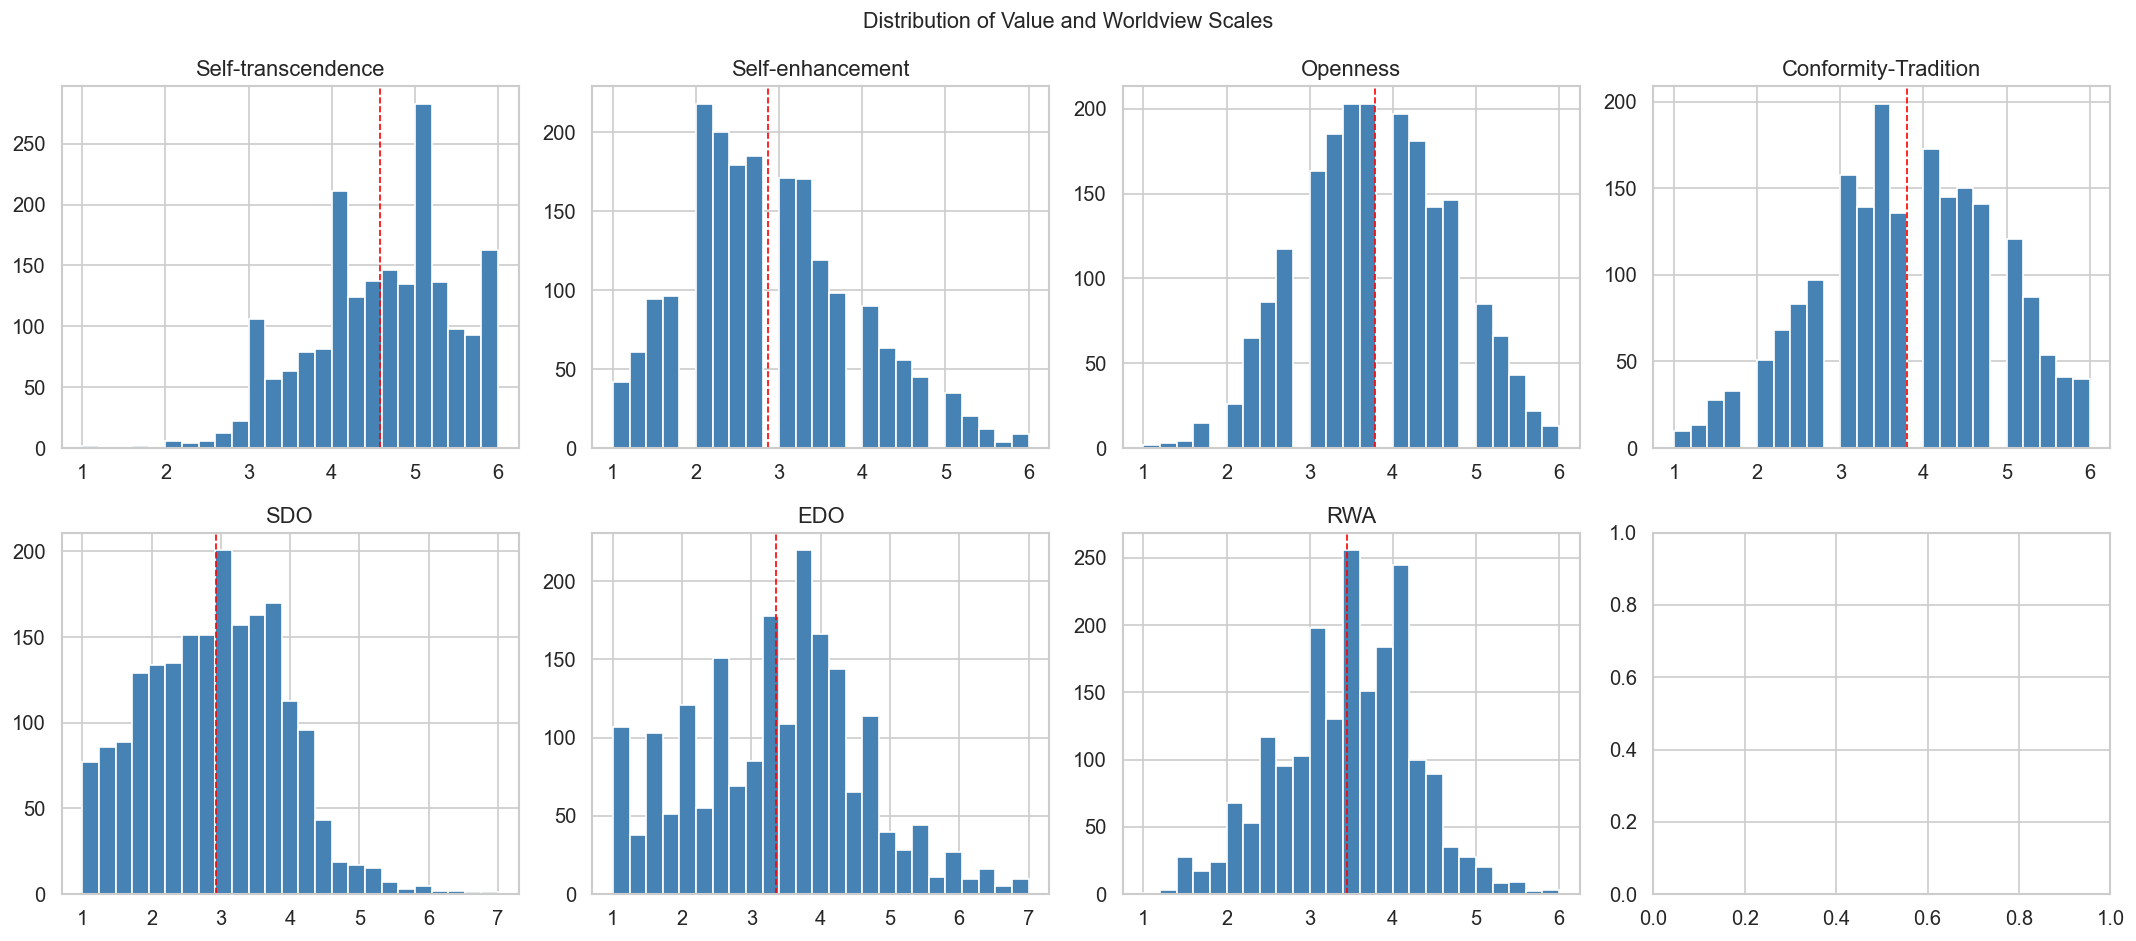

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flat

for ax, (name, col) in zip(axes_flat, VALUE_COLS.items()):
    df[col].hist(bins=25, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(name)
    ax.axvline(df[col].mean(), color="red", ls="--", linewidth=1)

# Hide unused subplot
for ax in list(axes_flat)[len(VALUE_COLS):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Value and Worldview Scales", fontsize=13)
plt.tight_layout()
plt.show()

All seven scales show continuous, roughly bell-shaped distributions with reasonable spread — no ceiling/floor effects. **SDO** is right-skewed (most people score low, consistent with the general finding that social dominance orientation is a minority disposition). **Self-transcendence** is left-skewed, with a concentration of high scores. These distributional properties are important for the ABM: the agent population will inherit real heterogeneity in underlying values.

## 6. Climate Emotions

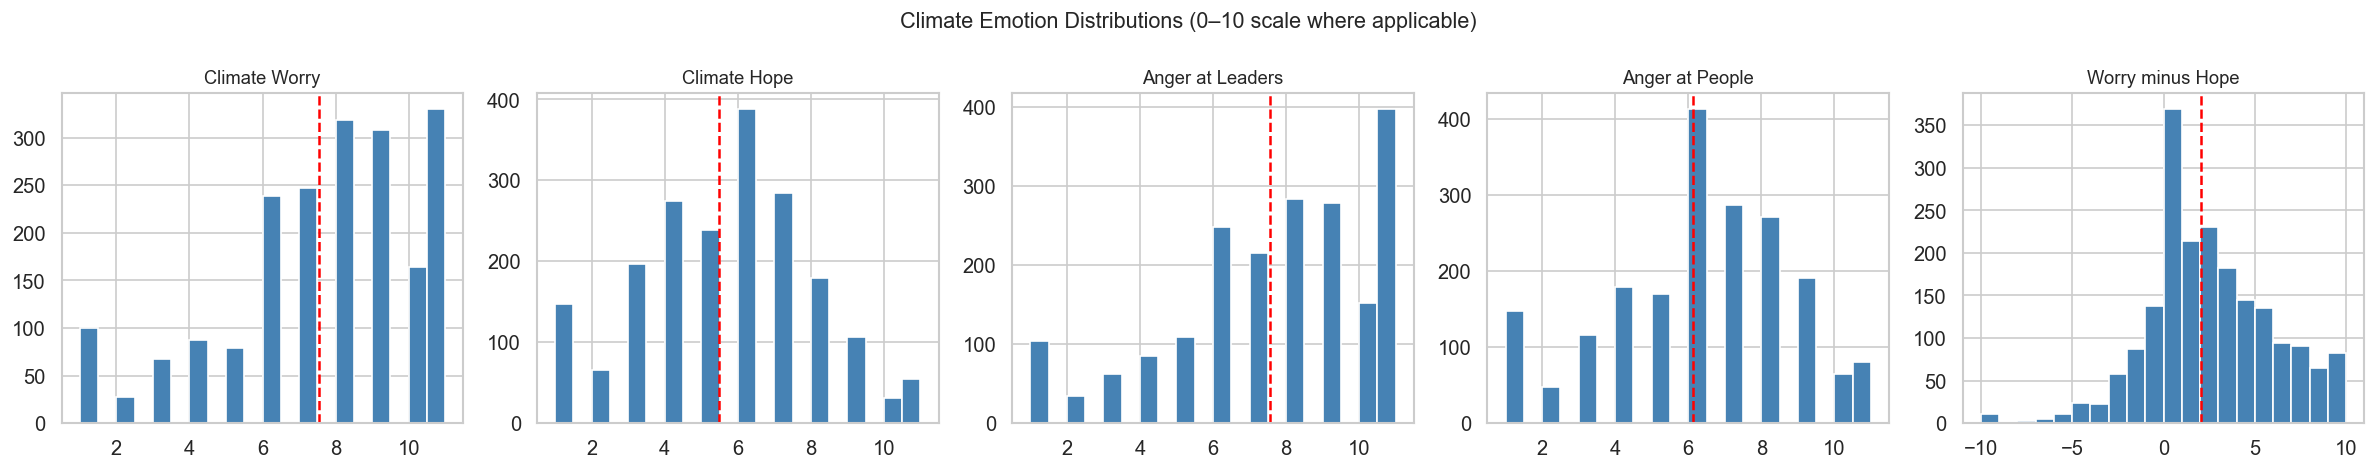

In [14]:
EMOTION_COLS = {
    "Climate Worry": "ClimateWorry",
    "Climate Hope": "ClimateHope",
    "Anger at Leaders": "ClimateAngerLeaders",
    "Anger at People": "ClimateAngerPeople",
    "Worry minus Hope": "WorryMinusHope",
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for ax, (name, col) in zip(axes, EMOTION_COLS.items()):
    df[col].hist(bins=20, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(name, fontsize=11)
    ax.axvline(df[col].mean(), color="red", ls="--")

fig.suptitle("Climate Emotion Distributions (0–10 scale where applicable)", fontsize=13)
plt.tight_layout()
plt.show()

**Climate emotion highlights:**
- **Climate Worry** is strongly left-skewed — most respondents report high worry (7–10), with the modal response at 10.
- **Climate Hope** is more normally distributed, centred around 5–6 — moderately hopeful but far from ceiling.
- **Anger at Leaders** is heavily left-skewed (mode = 10), indicating widespread frustration with political inaction.
- **Anger at People** is more evenly spread, peaking around 5–6.
- **Worry minus Hope** centres near 0 but skews slightly positive, meaning worry slightly outweighs hope for most respondents.

## 7. Policy Support by Subgroups

How does support vary by political orientation, Brexit vote, UKGE2019 vote, age, and gender?

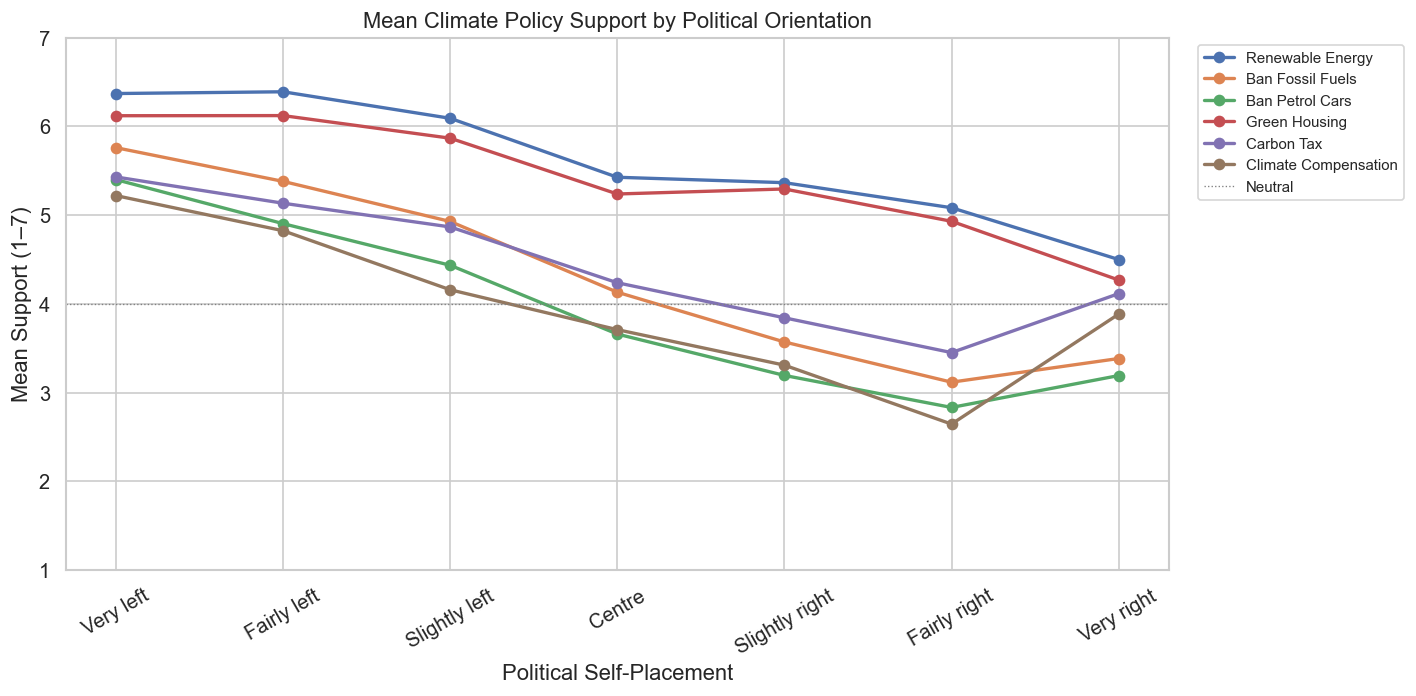

In [15]:
# ── Mean policy support by Political Left-Right ─────────────
df_lr = df.dropna(subset=["Political_Left_Right"]).copy()
df_lr["Political_LR"] = df_lr["Political_Left_Right"].astype(int).map(POLITICS_MAP)
lr_order = [POLITICS_MAP[i] for i in range(1, 8)]  # exclude Don't know
df_lr = df_lr[df_lr["Political_LR"].isin(lr_order)]

fig, ax = plt.subplots(figsize=(12, 6))
for name, col in POLICY_COLS.items():
    means = df_lr.groupby("Political_LR")[col].mean().reindex(lr_order)
    ax.plot(lr_order, means.values, marker="o", linewidth=2, label=name)

ax.axhline(4, color="grey", ls=":", linewidth=0.8, label="Neutral")
ax.set_ylabel("Mean Support (1–7)")
ax.set_xlabel("Political Self-Placement")
ax.set_title("Mean Climate Policy Support by Political Orientation")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_ylim(1, 7)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Political orientation is the single strongest predictor of policy support.** All six policies show a monotonic decline from left to right. Renewable Energy and Green Housing remain above the neutral line (4) even among "Very right" respondents, but the contested policies (Ban Petrol Cars, Climate Compensation) drop below neutral already at "Centre" and fall to ~2.5–3.0 for "Fairly right" respondents. This ~3-point left-to-right gradient across the most divisive policies is a key empirical input for the ABM's exposure assignment logic.

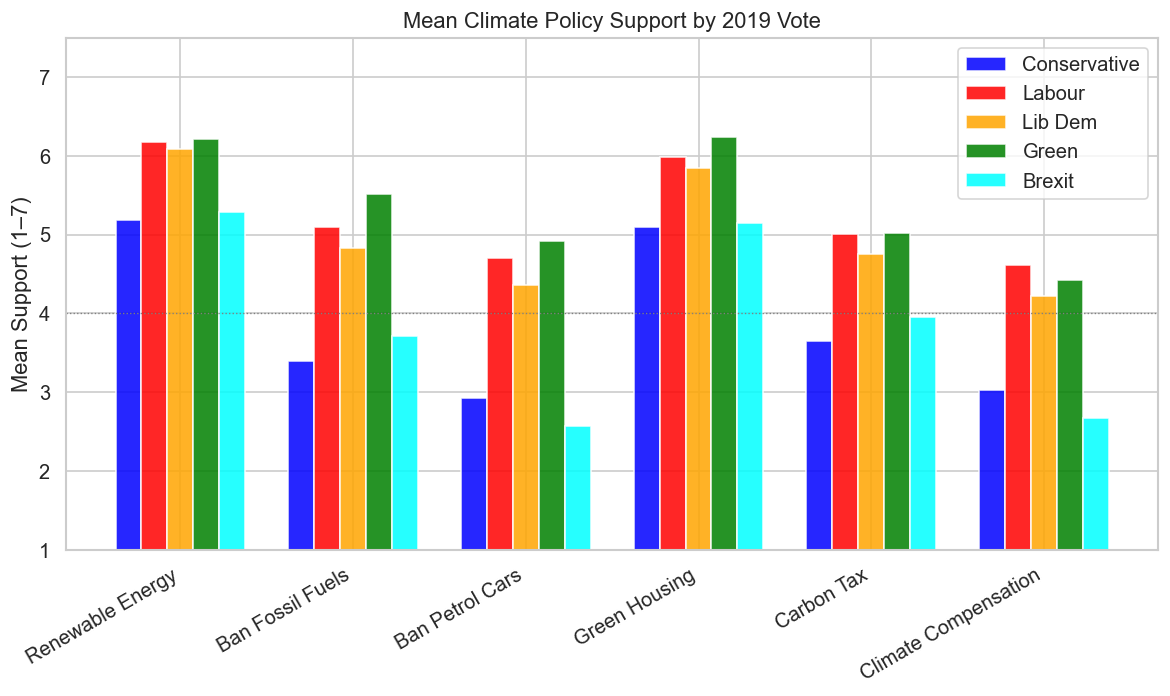

In [16]:
# ── Mean policy support by 2019 Vote ───────────────────────
df_ge = df.copy()
df_ge["GE2019"] = df_ge["Vote2019R"].map(GE2019_MAP)
ge_parties = ["Conservative", "Labour", "Lib Dem", "Green", "Brexit"]
df_ge = df_ge[df_ge["GE2019"].isin(ge_parties)]

fig, ax = plt.subplots(figsize=(10, 6))
party_colors = {"Conservative": "blue", "Labour": "red", "Lib Dem": "orange",
                "Green": "green", "Brexit": "cyan"}

policy_names_list = list(POLICY_COLS.keys())
x = np.arange(len(policy_names_list))
width = 0.15

for i, party in enumerate(ge_parties):
    means = [df_ge[df_ge["GE2019"] == party][col].mean() for col in POLICY_COLS.values()]
    ax.bar(x + i * width, means, width, label=party, color=party_colors[party], alpha=0.85)

ax.axhline(4, color="grey", ls=":", linewidth=0.8)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(policy_names_list, rotation=30, ha="right")
ax.set_ylabel("Mean Support (1–7)")
ax.set_title("Mean Climate Policy Support by 2019 Vote")
ax.legend()
ax.set_ylim(1, 7.5)
plt.tight_layout()
plt.show()

**Party differences are stark.** Green voters consistently show the highest support across all policies (means 5.0–6.3), while Conservative and Brexit Party voters are the lowest. The gap is largest for **Ban Petrol Cars** (Green ~4.9 vs Brexit ~2.6, a 2.3-point gap) and **Climate Compensation** (Green ~4.4 vs Conservative ~3.0). Labour and Lib Dem voters sit between, closer to the Green end. Notably, even Conservative voters support Renewable Energy (mean ~5.2) — the one policy with genuine cross-party appeal.

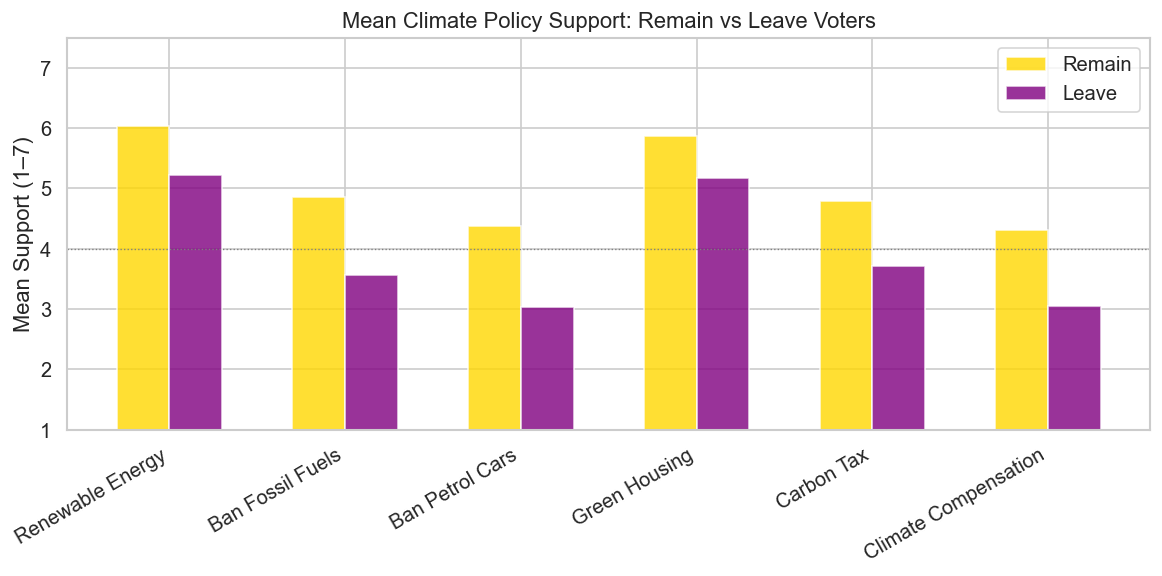

In [17]:
# ── Mean policy support by Brexit Vote ─────────────────────
df_bx = df.copy()
df_bx["Brexit"] = df_bx["pastvote_EURef"].map(BREXIT_MAP)
df_bx = df_bx[df_bx["Brexit"].isin(["Remain", "Leave"])]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(policy_names_list))
width = 0.3

for i, vote in enumerate(["Remain", "Leave"]):
    means = [df_bx[df_bx["Brexit"] == vote][col].mean() for col in POLICY_COLS.values()]
    color = "gold" if vote == "Remain" else "purple"
    ax.bar(x + i * width, means, width, label=vote, color=color, alpha=0.8)

ax.axhline(4, color="grey", ls=":", linewidth=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(policy_names_list, rotation=30, ha="right")
ax.set_ylabel("Mean Support (1–7)")
ax.set_title("Mean Climate Policy Support: Remain vs Leave Voters")
ax.legend()
ax.set_ylim(1, 7.5)
plt.tight_layout()
plt.show()

**Remain voters consistently outperform Leave voters** on every policy, with gaps of ~0.8–1.4 points. The divide is largest for **Ban Petrol Cars** (Remain ~4.4 vs Leave ~3.0) and **Climate Compensation** (Remain ~4.3 vs Leave ~3.0). Leave voters sit below neutral on four of six policies. This Remain/Leave cleavage — which the ABM uses as a primary signal for political exposure assignment — is empirically well-justified as a proxy for climate attitudes.

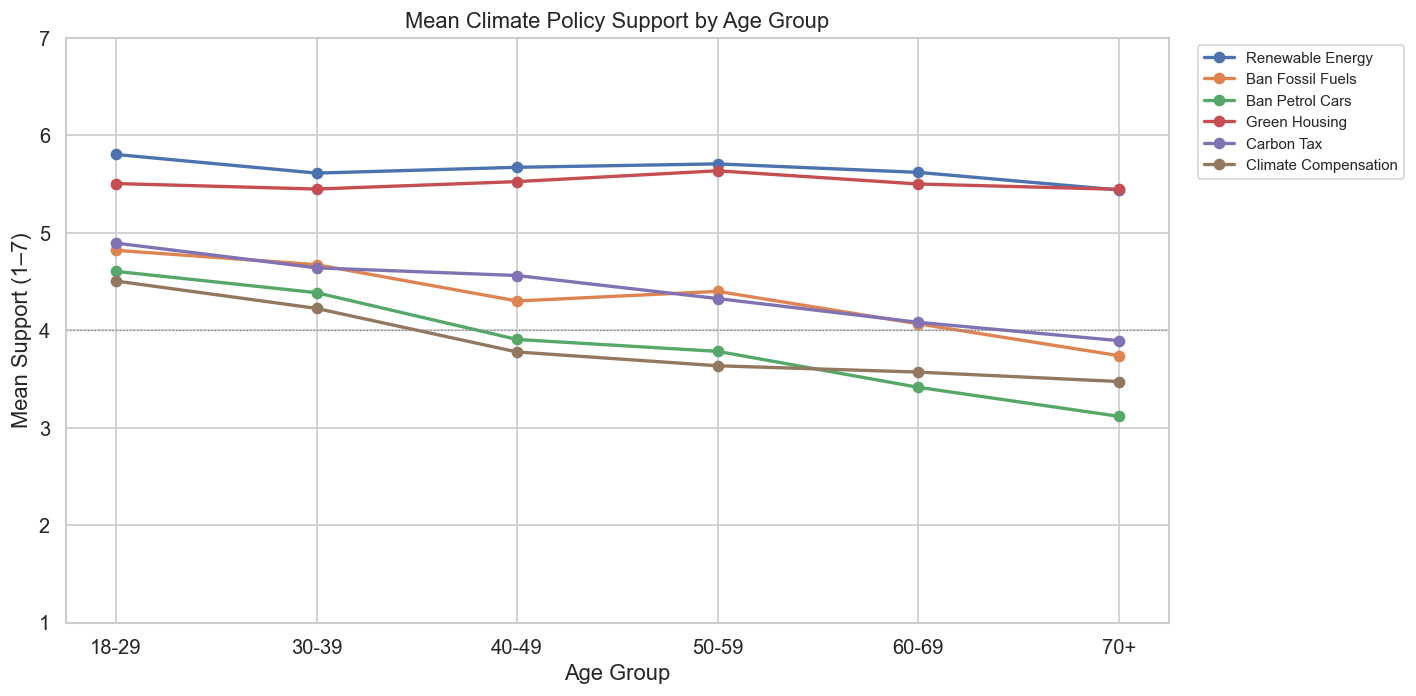

In [18]:
# ── Policy support by age group ────────────────────────────
df_age = df.copy()
df_age["Age Group"] = pd.cut(df_age["age"].clip(upper=85),
                              bins=[17, 29, 39, 49, 59, 69, 85],
                              labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"])

fig, ax = plt.subplots(figsize=(12, 6))
for name, col in POLICY_COLS.items():
    means = df_age.groupby("Age Group", observed=True)[col].mean()
    ax.plot(means.index.astype(str), means.values, marker="o", linewidth=2, label=name)

ax.axhline(4, color="grey", ls=":", linewidth=0.8)
ax.set_ylabel("Mean Support (1–7)")
ax.set_xlabel("Age Group")
ax.set_title("Mean Climate Policy Support by Age Group")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_ylim(1, 7)
plt.tight_layout()
plt.show()

**Age effects are modest but consistent.** Younger respondents (18–29) show slightly higher support across most policies, with a gentle decline through to the 70+ group. The gradient is steepest for **Ban Petrol Cars** (18–29: ~4.6, 70+: ~3.1) and **Climate Compensation** (18–29: ~4.5, 70+: ~3.5). Renewable Energy and Green Housing remain above 5.0 across all age groups, showing resilience to age effects.

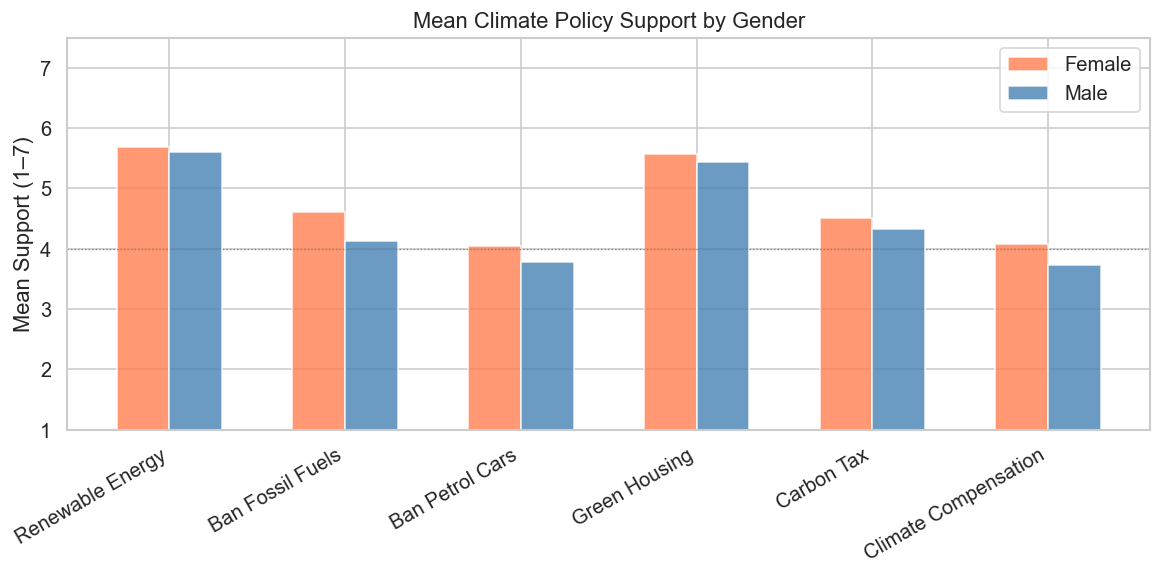

In [19]:
# ── Policy support by Gender ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(policy_names_list))
width = 0.3

for i, (gender_val, label) in enumerate([(0, "Female"), (1, "Male")]):
    means = [df[df["male_dummy"] == gender_val][col].mean() for col in POLICY_COLS.values()]
    ax.bar(x + i * width, means, width, label=label, color=["coral", "steelblue"][i], alpha=0.8)

ax.axhline(4, color="grey", ls=":", linewidth=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(policy_names_list, rotation=30, ha="right")
ax.set_ylabel("Mean Support (1–7)")
ax.set_title("Mean Climate Policy Support by Gender")
ax.legend()
ax.set_ylim(1, 7.5)
plt.tight_layout()
plt.show()

**Gender differences are small.** Women show marginally higher support than men on most policies (typically 0.1–0.4 points), with the largest gap on **Ban Fossil Fuels** (~4.6 vs ~4.1). Both genders are above neutral for Renewable Energy and Green Housing, and both hover near neutral for Ban Petrol Cars and Climate Compensation. Gender is not a strong predictor of climate policy attitudes in this sample.

## 8. Correlation Structure: Policies, Values, and Politics

How do psychological values and political orientation relate to climate policy support?

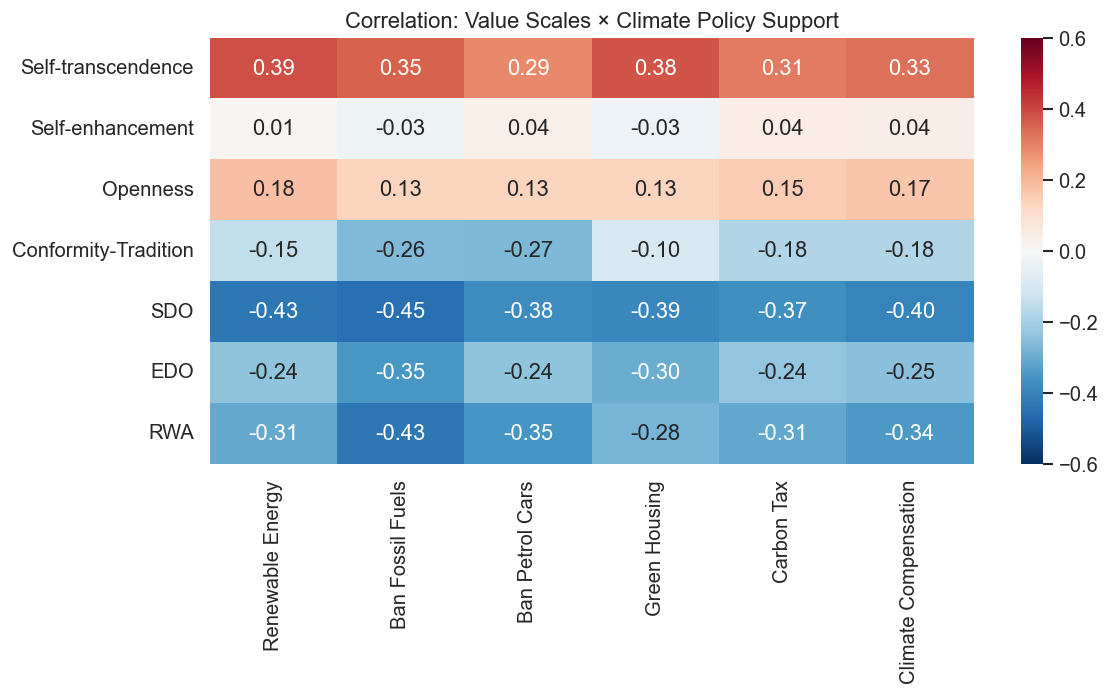

In [20]:
# ── Correlation: values × policy support ───────────────────
value_cols_list = list(VALUE_COLS.values())
policy_cols_list = list(POLICY_COLS.values())

cross_corr = df[value_cols_list + policy_cols_list].corr().loc[
    [VALUE_COLS[k] for k in VALUE_COLS],
    [POLICY_COLS[k] for k in POLICY_COLS]
]
cross_corr.index = list(VALUE_COLS.keys())
cross_corr.columns = list(POLICY_COLS.keys())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.6, vmax=0.6, ax=ax)
ax.set_title("Correlation: Value Scales × Climate Policy Support")
plt.tight_layout()
plt.show()

**Value–policy correlations reveal two clear clusters:**
- **Pro-climate values**: Self-transcendence (r ≈ +0.29 to +0.39) and Openness (r ≈ +0.13 to +0.18) are positively associated with policy support across all six policies.
- **Anti-climate values**: SDO (r ≈ −0.37 to −0.45), RWA (r ≈ −0.28 to −0.43), and EDO (r ≈ −0.24 to −0.35) are consistently negatively associated. SDO and RWA show the strongest negative correlations, especially with Ban Fossil Fuels and Climate Compensation.
- **Self-enhancement** shows near-zero correlations (r ≈ 0.01–0.04) — it is irrelevant to climate attitudes.
- These patterns confirm the theoretical expectation from Schwartz's value circumplex and social dominance theory.

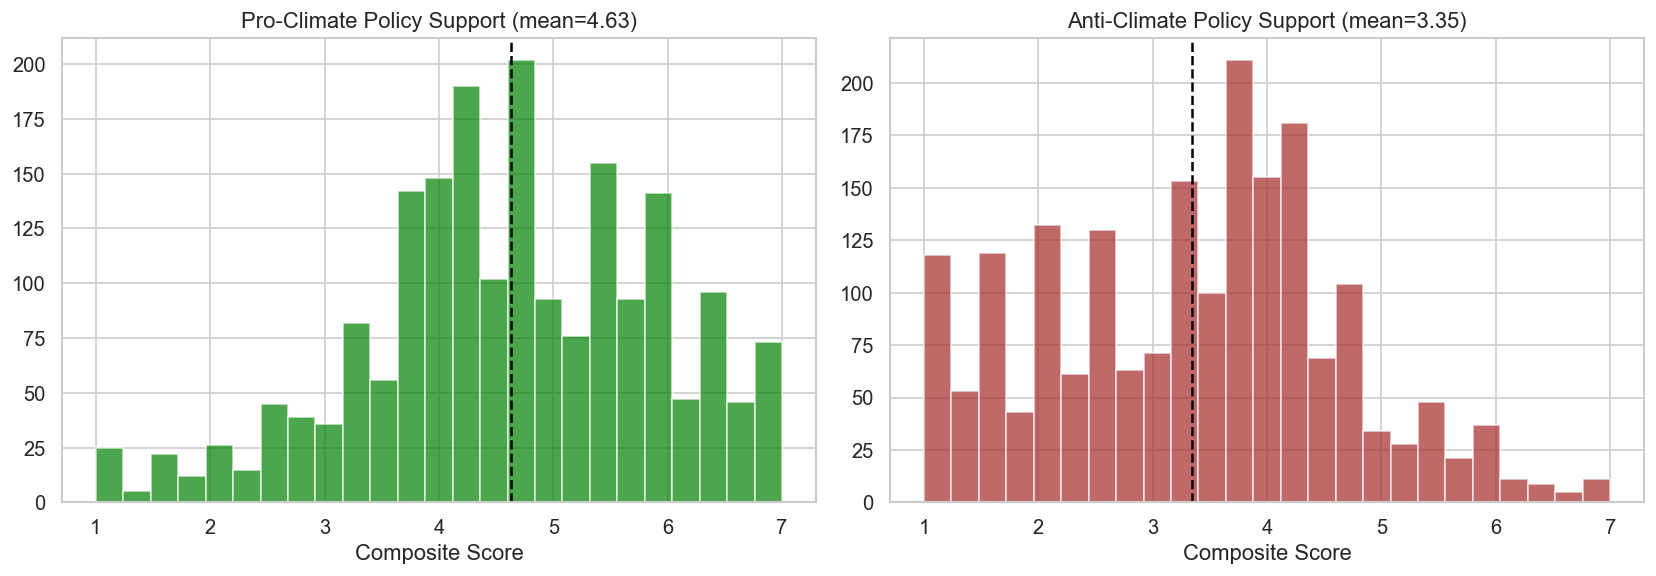

Correlation between Pro and Anti composite scores: -0.748


In [21]:
# ── Composite support scores (pro-climate vs anti-climate) ─
# ProClimatePolSupp and AntiClimatePolSupp are pre-computed in the dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
df["ProClimatePolSupp"].hist(bins=25, ax=ax, color="green", alpha=0.7, edgecolor="white")
ax.axvline(df["ProClimatePolSupp"].mean(), color="black", ls="--")
ax.set_title(f"Pro-Climate Policy Support (mean={df['ProClimatePolSupp'].mean():.2f})")
ax.set_xlabel("Composite Score")

ax = axes[1]
df["AntiClimatePolSupp"].hist(bins=25, ax=ax, color="brown", alpha=0.7, edgecolor="white")
ax.axvline(df["AntiClimatePolSupp"].mean(), color="black", ls="--")
ax.set_title(f"Anti-Climate Policy Support (mean={df['AntiClimatePolSupp'].mean():.2f})")
ax.set_xlabel("Composite Score")

plt.tight_layout()
plt.show()

print(f"Correlation between Pro and Anti composite scores: {df['ProClimatePolSupp'].corr(df['AntiClimatePolSupp']):.3f}")

The pre-computed **Pro-Climate** composite (mean = 4.63) leans supportive, while the **Anti-Climate** composite (mean = 3.35) leans oppositional — confirming the sample's net pro-climate tilt. Both distributions are broad and roughly symmetric, showing substantial variation. The correlation between the two composites (printed below the chart) indicates the degree to which pro- and anti-climate policy support are opposing ends of one dimension versus partially independent attitudes.

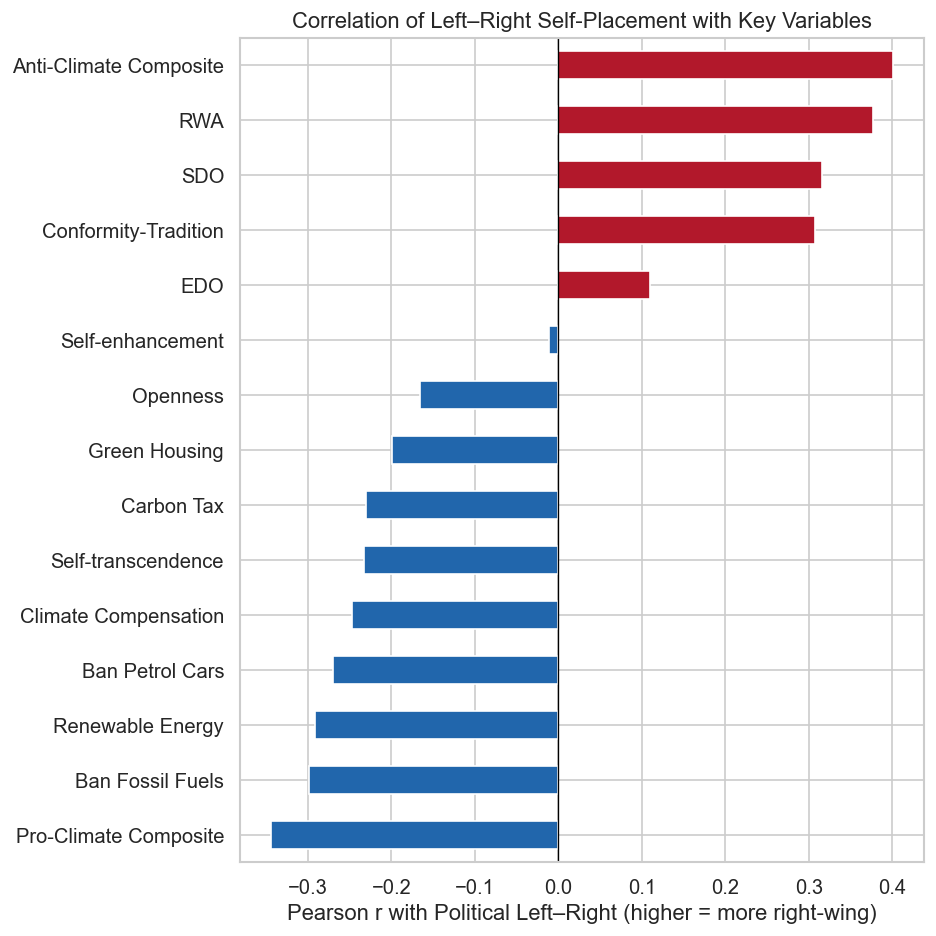

In [22]:
# ── Key correlations with Political Left-Right ─────────────
lr_col = "Political_Left_Right"
target_cols = list(POLICY_COLS.values()) + list(VALUE_COLS.values()) + ["ProClimatePolSupp", "AntiClimatePolSupp"]
target_names = list(POLICY_COLS.keys()) + list(VALUE_COLS.keys()) + ["Pro-Climate Composite", "Anti-Climate Composite"]

lr_corrs = df[[lr_col] + target_cols].corr()[lr_col].drop(lr_col)
lr_corrs.index = target_names
lr_corrs = lr_corrs.sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#2166ac" if v < 0 else "#b2182b" for v in lr_corrs]
lr_corrs.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r with Political Left–Right (higher = more right-wing)")
ax.set_title("Correlation of Left–Right Self-Placement with Key Variables")
plt.tight_layout()
plt.show()

**Left–Right self-placement integrates with everything.** Right-wing identification correlates most strongly with the Anti-Climate Composite (r ≈ +0.40), RWA (+0.37), SDO (+0.31), and Conformity-Tradition (+0.30). Conversely, it correlates negatively with the Pro-Climate Composite (r ≈ −0.30), all six individual policies (r ≈ −0.10 to −0.23), and Self-transcendence (−0.20). This confirms that left-right orientation serves as a reliable summary variable connecting psychological values to concrete policy attitudes — supporting its use (via Brexit and UKGE2019 vote) as the ABM's exposure assignment signal.

## Summary

Key findings to highlight in the paper introduction:

- **Renewable Energy** and **Green Housing** enjoy strong net support (>60% support vs ~7% oppose)
- **Ban Petrol Cars** and **Climate Compensation** are divisive — nearly split between support and opposition
- **Carbon Tax** and **Ban Fossil Fuels** sit in the middle — majority neutral-to-supportive
- Political orientation is a strong predictor: support drops monotonically from left to right across all policies
- Remain voters consistently support all policies more than Leave voters
- Psychological values (SDO, EDO, RWA) are negatively correlated with climate policy support; Self-transcendence and Openness are positively correlated
- The sample is roughly representative of UK demographics (47% male, median age 47, majority White)